In [2]:
import csv
import os
import pandas as pd
import matplotlib.pyplot as plt

In [34]:
#load data
attacks = pd.read_csv("pirate_attacks.csv")
indicators = pd.read_csv("country_indicators.csv")
#names = pd.read_csv("country_codes.csv")

In [39]:
#date column to datetime
attacks['date'] = pd.to_datetime(attacks['date'])
#year
attacks['year'] = attacks['date'].dt.year

#count attacks per year
attacks_per_year = attacks.groupby('year').size()

## Counting attacks by year

In [48]:
attacks_per_year = attacks["year"].value_counts().sort_index().reset_index()
attacks_per_year.columns = ["year", "attack_count"]

print(attacks_per_year)

    year  attack_count
0   1993           101
1   1994            95
2   1995           166
3   1996           175
4   1997           232
5   1998           186
6   1999           299
7   2000           469
8   2001           335
9   2002           369
10  2003           440
11  2004           314
12  2005           277
13  2006           236
14  2007           261
15  2008           293
16  2009           404
17  2010           445
18  2011           438
19  2012           296
20  2013           264
21  2014           243
22  2015           250
23  2016           186
24  2017           186
25  2018           202
26  2019           159
27  2020           190


## Plotting overall attack trends
In the graph, the lines show the selected time periods

/var/folders/7k/07rgs_w97pn8b2z7y1554bz40000gn/T/ipykernel_3233/872724865.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


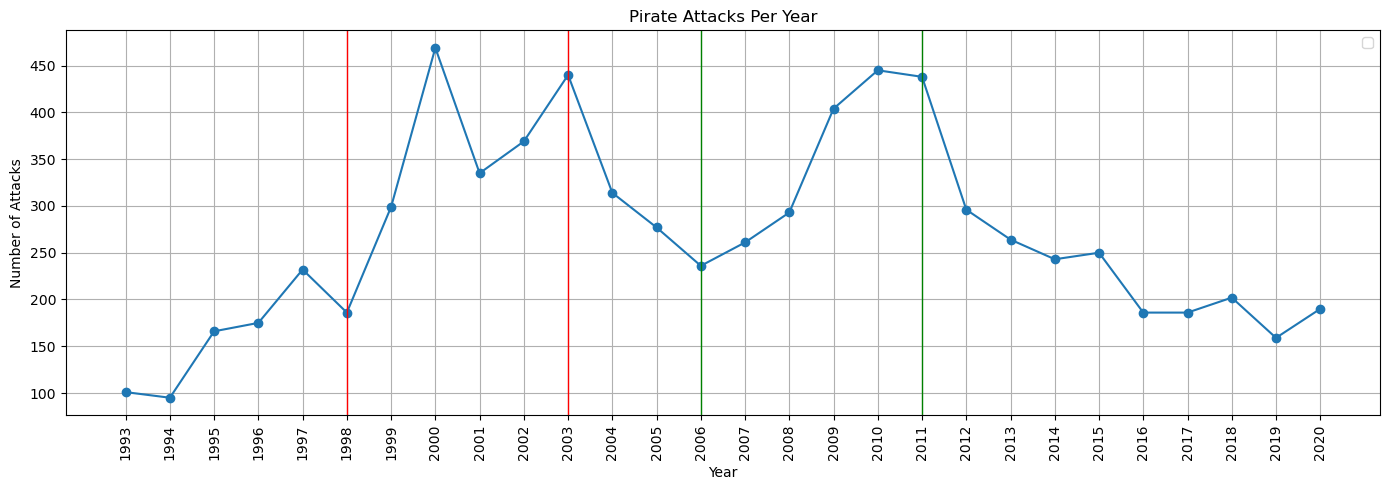

In [41]:
plt.figure(figsize=(14, 5))
plt.plot(attacks_per_year["year"], attacks_per_year["attack_count"], marker="o")
plt.title("Pirate Attacks Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Attacks")
plt.xticks(attacks_per_year["year"], rotation=90)

plt.axvline(x=1998, color="red", linestyle="-", linewidth=1)
plt.axvline(x=2003, color="red", linestyle="-", linewidth=1)
plt.axvline(x=2006, color="green", linestyle="-", linewidth=1)
plt.axvline(x=2011, color="green", linestyle="-", linewidth=1)
#plt.axvline(x=2015, color="red", linestyle="-", linewidth=1)


plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [57]:
country_gdp = indicators[['country', 'year', 'industryofgdp', 'totalgr', 'unemployment_rate', 'total_military', 'population', 'homicide_rate', 'total_fisheries_per_ton', 'GDP', 'corruption_index', ]]

#merge attacks and indicators dataset for whole period
merged_df = pd.merge(
    attacks,
    country_gdp,
    left_on=['eez_country', 'year'],
    right_on=['country', 'year'],
    how='left'
)

#drop unused columns from merge
merged_df = merged_df.drop(columns=['country', 'date', 'time', 'longitude', 'latitude', 'location_description', 'nearest_country', 'shore_distance',
                                    'shore_longitude', 'shore_latitude', 'attack_description', 'vessel_name', 'vessel_type', 'vessel_status', 'data_source', 'attack_type'])

## Plotting attacks overall and GDP

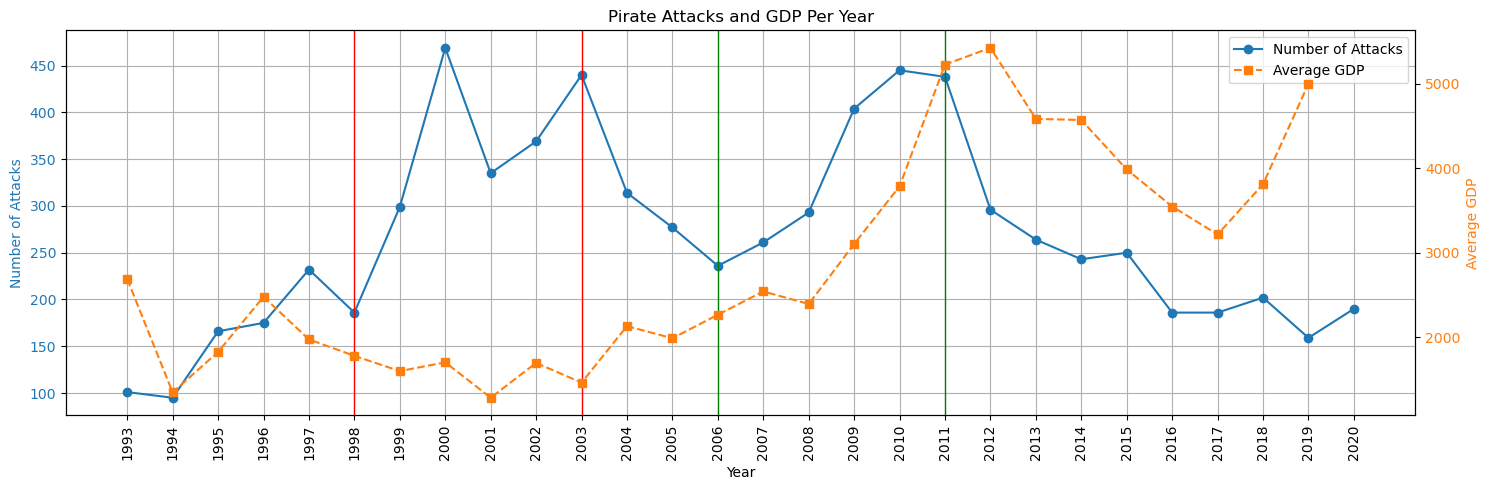

In [44]:
import matplotlib.pyplot as plt
import pandas as pd

#data by year to get the total count of attacks and the average GDP
df_yearly = (
    merged_df.groupby("year")
    .agg(number_of_attacks=("year", "size"), mean_gdp=("GDP", "mean"))
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(15, 5))

#plot 1 attacks (Left Y-Axis)
color_attacks = "tab:blue"
ax1.set_xlabel("Year")
ax1.set_ylabel("Number of Attacks", color=color_attacks)
line1 = ax1.plot(
    df_yearly["year"],
    df_yearly["number_of_attacks"],
    marker="o",
    color=color_attacks,
    label="Number of Attacks",
)
ax1.tick_params(axis="y", labelcolor=color_attacks)
ax1.grid(True)

#plot 2 GDP (right y axis)
ax2 = ax1.twinx()
color_gdp = "tab:orange"
ax2.set_ylabel("Average GDP", color=color_gdp)
line2 = ax2.plot(
    df_yearly["year"],
    df_yearly["mean_gdp"],
    marker="s",
    linestyle="--",
    color=color_gdp,
    label="Average GDP",
)
ax2.tick_params(axis="y", labelcolor=color_gdp)

# Format X-axis ticks (vertical rotation matching the template image)
ax1.set_xticks(df_yearly["year"])
ax1.set_xticklabels(df_yearly["year"], rotation=90)

# Add the specific colored vertical milestone lines from the template image
ax1.axvline(x=1998, color="red", linestyle="-", linewidth=1)
ax1.axvline(x=2003, color="red", linestyle="-", linewidth=1)
ax1.axvline(x=2006, color="green", linestyle="-", linewidth=1)
ax1.axvline(x=2011, color="green", linestyle="-", linewidth=1)

#combine legend and title
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper right")
plt.title("Pirate Attacks and GDP Per Year")

plt.tight_layout()
plt.show()

## Top 20 countries with most attacks

In [45]:
# Count attacks per country (both eez and nearest)
eez_counts = attacks["eez_country"].value_counts().reset_index()
eez_counts.columns = ["eez_country", "attack_count"]

print(eez_counts.head(20))

   eez_country  attack_count
0          IDN          1982
1          NGA           557
2          MYS           476
3          BGD           469
4          YEM           468
5          IND           338
6          PHL           229
7          VNM           199
8          SOM           163
9          BRA           153
10         CHN           144
11         PER           122
12         TZA           110
13         VEN           103
14         ECU            93
15         GHA            86
16         COL            85
17         OMN            83
18         THA            79
19         GIN            78


attack_type
Boarded       3421
Attempted     1999
Boarding      1367
Hijacked       511
NaN            120
Fired Upon      73
Suspicious      16
Explosion        3
Detained         1
Name: count, dtype: int64


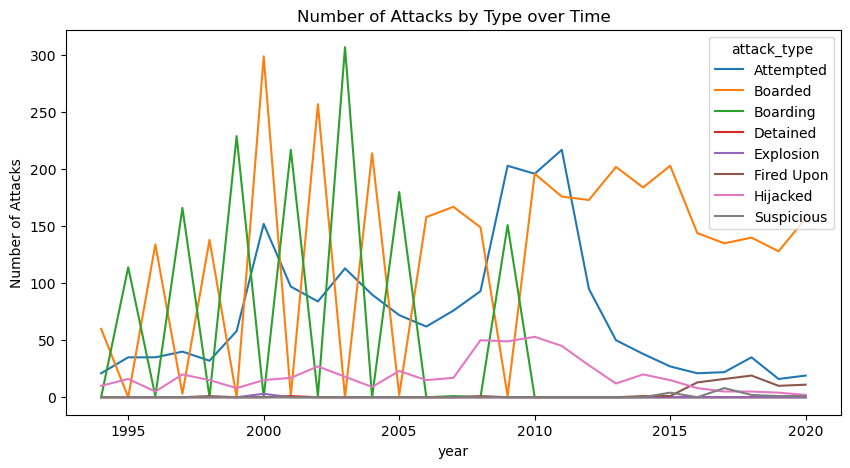

In [61]:
#count how many of each type
print(attacks["attack_type"].value_counts(dropna=False))

#by year
attacks["year"] = pd.to_datetime(attacks["date"]).dt.year
attacks_by_year_type = attacks.groupby(["year", "attack_type"]).size().unstack(fill_value=0)
attacks_by_year_type.plot(kind="line", figsize=(10, 5))
plt.title("Number of Attacks by Type over Time")
plt.ylabel("Number of Attacks")
plt.show()